In [1]:
# Run this once in terminal: pip install opencv-python
import cv2
import matplotlib.pyplot as plt

In [2]:
# OpenCV comes with a built-in face detector — no training needed!
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
print("Haar Cascade loaded successfully!")

Haar Cascade loaded successfully!


Faces detected: 14


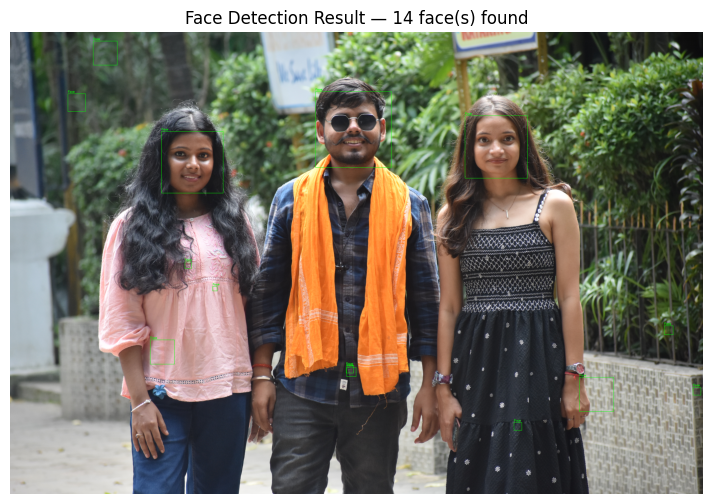

Output saved as output_detected.jpg


In [7]:
import os

def detect_faces(image_path):
    # Check if file exists first
    if not os.path.exists(image_path):
        print(f"ERROR: File not found → {image_path}")
        print(f"Looking in folder: {os.getcwd()}")
        print(f"Files available here: {os.listdir('.')}")
        return []
    
    # Load image
    img = cv2.imread(image_path)
    
    if img is None:
        print("ERROR: Image could not be loaded. Try a .jpg or .png file.")
        return []
    
    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Detect faces
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )
    
    print(f"Faces detected: {len(faces)}")
    
    # Draw bounding boxes
    for (x, y, w, h) in faces:
        cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.putText(img, 'Face', (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2)
    
    # Show result
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 6))
    plt.imshow(img_rgb)
    plt.title(f'Face Detection Result — {len(faces)} face(s) found')
    plt.axis('off')
    plt.show()
    
    cv2.imwrite('output_detected.jpg', img)
    print("Output saved as output_detected.jpg")
    
    return faces

faces = detect_faces('DSC_0001.JPG')

In [4]:
def live_face_detection():
    cap = cv2.VideoCapture(0)  # 0 = default webcam
    print("Press 'q' to quit")
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, 1.1, 5, minSize=(30,30))
        
        for (x, y, w, h) in faces:
            cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
            cv2.putText(frame, f'Face', (x, y-10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2)
        
        cv2.putText(frame, f'Faces: {len(faces)}', (10, 30),
                   cv2.FONT_HERSHEY_SIMPLEX, 1, (255,0,0), 2)
        cv2.imshow('Live Face Detection', frame)
        
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    
    cap.release()
    cv2.destroyAllWindows()

live_face_detection()

Press 'q' to quit
